# Faunari · Notebook 04 — Baseline Danger Model (frozen-backbone linear probe)

The **Phase-1 opener**. We turn the leakage-safe corpus from nb 03 into a first,
honest **binary danger classifier** — and, before trusting any model, we look at the
**embedding space itself**. Everything is framed by the project's **asymmetric-error**
objective: a venomous snake misread as *safe* can kill, so the headline metric is
**recall on the venomous class**, never accuracy.

**What this notebook does (in order)**
1. **Setup & labels** — load `master_index.csv`, apply the **conservative override**
   (force the 5 *Rhabdophis* `needs_review` species to `venomous` — "default to danger
   when unsure"), set & log all seeds and config.
2. **Frozen embeddings** — MobileNetV3-Large (ImageNet, frozen) → 960-d pooled vector
   per image. **Embed once, cache to disk**, reuse for Part A and Part B (this is what
   makes ~5.8k images tractable on CPU).
3. **Part A — embedding-space diagnostic** — PCA(50)→UMAP(2D); colour by danger and by
   source; highlight the big-four and the look-alike pairs; quantify separability and
   surface suspected mislabels / leakage blobs. *(Qualitative — informs the plan.)*
4. **Part B — baseline classifier** — cost-sensitive logistic-regression **linear probe**
   on the frozen features (fit on `train` only, scaler inside a `Pipeline`), threshold
   tuned on `val` for high venomous recall, evaluated on **`test` and `hardcase`
   separately**, with a full **dangerous→safe** error analysis.

> **Scope:** this is a *linear probe on frozen features*. Full fine-tuning of the
> backbone is **out of scope** for this baseline (future work).

**Required libs:** `torch torchvision scikit-learn umap-learn` (+ the Phase-0 stack:
`pandas numpy matplotlib pillow tqdm`).

## 0 · Setup — imports, paths, seeds, config

Path resolution matches nb 01–03 exactly (works from `Trials/` or the project root).
We set **every** RNG seed (`random`, `numpy`, `torch`) and log the full config in one
place so the run is reproducible and auditable.

In [1]:
from __future__ import annotations

import os
import json
import random
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile, UnidentifiedImageError

try:
    from tqdm.auto import tqdm
except ImportError:  # tqdm is optional; degrade to a no-op wrapper (same pattern as nb 03).
    def tqdm(it, **_):  # type: ignore
        return it

# Truncated JPEGs are common in scraped data; allow load but still flag unreadable files (nb 03).
ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore", category=UserWarning, module="PIL")

# Resolve repo root whether run from Trials/ or the project root (same rule as nb 01/02/03).
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Trials" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
TAXONOMY_DIR = DATA_DIR / "taxonomy"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Processed dir: {PROCESSED_DIR}  (exists={PROCESSED_DIR.exists()})")
print(f"Taxonomy dir : {TAXONOMY_DIR}  (exists={TAXONOMY_DIR.exists()})")

Project root : E:\Coding_Notes\Faunari
Processed dir: E:\Coding_Notes\Faunari\data\processed  (exists=True)
Taxonomy dir : E:\Coding_Notes\Faunari\data\taxonomy  (exists=True)


C:\Users\Dhruv\miniforge3\envs\faunari\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Reproducibility: one place to seed every RNG, logged for the record. ---
SEED = 42


def set_all_seeds(seed: int) -> None:
    '''Seed python, numpy and torch RNGs so the whole pipeline is reproducible.'''
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    import torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_all_seeds(SEED)
print(f"All seeds set to {SEED} (random, numpy, torch, PYTHONHASHSEED).")

All seeds set to 42 (random, numpy, torch, PYTHONHASHSEED).


In [3]:
# --- Central config: backbone, weights, embedding dim, cache paths, cost weights, threshold rule. ---
@dataclass(frozen=True)
class Config:
    '''Single source of truth for every knob in this notebook (logged below).'''
    seed: int = SEED
    backbone: str = "mobilenet_v3_large"
    weights: str = "IMAGENET1K_V2"
    embedding_dim: int = 960            # MobileNetV3-Large pooled penultimate features.
    batch_size: int = 64
    num_workers: int = 0               # 0 = safe on Windows notebooks (avoids spawn issues).
    pca_components: int = 50           # PCA before UMAP (denoise + speed), per the brief.
    umap_neighbors: int = 30
    umap_min_dist: float = 0.1
    positive_class: str = "venomous"   # the dangerous (positive) class for all metrics.
    # Cost-sensitive: penalize venomous->non_venomous (dangerous->safe) far more than reverse.
    venomous_class_weight: float = 6.0
    nonvenomous_class_weight: float = 1.0
    logreg_C: float = 1.0
    logreg_max_iter: int = 2000
    # Threshold rule (tuned on val): highest-recall threshold keeping venomous precision >= floor.
    target_recall: float = 0.98        # we WANT venomous recall >= this (the release gate).
    precision_floor: float = 0.60      # ...but refuse a degenerate "flag-everything" threshold.


CFG = Config()

EMB_NPY = PROCESSED_DIR / "embeddings_mobilenet_v3_large.npy"
EMB_INDEX = PROCESSED_DIR / "embeddings_mobilenet_v3_large_index.csv"

print("Config:")
print(json.dumps(asdict(CFG), indent=2))
print(f"\nEmbedding cache : {EMB_NPY}")
print(f"Embedding index : {EMB_INDEX}")

Config:
{
  "seed": 42,
  "backbone": "mobilenet_v3_large",
  "weights": "IMAGENET1K_V2",
  "embedding_dim": 960,
  "batch_size": 64,
  "num_workers": 0,
  "pca_components": 50,
  "umap_neighbors": 30,
  "umap_min_dist": 0.1,
  "positive_class": "venomous",
  "venomous_class_weight": 6.0,
  "nonvenomous_class_weight": 1.0,
  "logreg_C": 1.0,
  "logreg_max_iter": 2000,
  "target_recall": 0.98,
  "precision_floor": 0.6
}

Embedding cache : E:\Coding_Notes\Faunari\data\processed\embeddings_mobilenet_v3_large.npy
Embedding index : E:\Coding_Notes\Faunari\data\processed\embeddings_mobilenet_v3_large_index.csv


## 1 · Load the index & apply the **conservative override**

We load `master_index.csv` (the Phase-0 output) and the safety taxonomy. We **never
re-split** — `split` is used as-is.

> ### ⚠ CONSERVATIVE OVERRIDE (safety rule: *default to danger when unsure*)
> Any row whose species maps to `needs_review == True` in the taxonomy (the 5
> *Rhabdophis*) is **forced to `venomous`** for both training and evaluation. This
> implements the BRD rule and is applied as an explicit, logged step on a **copy**
> (`labels` = the single source of truth downstream). We report how many rows were
> overridden and how many actually **flipped** `non_venomous → venomous`.

In [4]:
def load_master_index(path: Path) -> pd.DataFrame:
    '''Load the Phase-0 per-image index; fail loudly if the expected columns are missing.'''
    df = pd.read_csv(path)
    required = {"path", "source", "species", "venom_label", "split"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"master_index.csv missing columns: {missing}")
    return df


def load_review_species(path: Path) -> set[str]:
    '''Return the set of scientific names flagged needs_review==True (the conservative-override targets).'''
    tax = pd.read_csv(path)
    return set(tax.loc[tax["needs_review"] == True, "scientific_name"])  # noqa: E712 (pandas mask)


master = load_master_index(PROCESSED_DIR / "master_index.csv")
review_species = load_review_species(TAXONOMY_DIR / "species_venom_map.csv")

print(f"master_index rows : {len(master)}")
print(f"split counts      : {master['split'].value_counts().to_dict()}")
print(f"venom (raw)       : {master['venom_label'].value_counts().to_dict()}")
print(f"needs_review spp  : {sorted(review_species)}")

master_index rows : 5823
split counts      : {'train': 3923, 'test': 833, 'val': 828, 'hardcase': 239}
venom (raw)       : {'non_venomous': 2959, 'venomous': 2864}
needs_review spp  : ['Rhabdophis helleri', 'Rhabdophis himalayanus', 'Rhabdophis leonardi', 'Rhabdophis plumbicolor', 'Rhabdophis plumbicolor plumbicolor']


In [5]:
def apply_conservative_override(df: pd.DataFrame, review_species: set[str]) -> pd.DataFrame:
    '''Return a COPY with venom_label forced to 'venomous' for any needs_review species.

    Implements 'default to danger when unsure'. Logs how many rows are overridden and how
    many actually flip non_venomous->venomous (the safety-relevant change).
    '''
    out = df.copy()
    mask = out["species"].isin(review_species)
    flipped = mask & (out["venom_label"] != "venomous")
    out.loc[mask, "venom_label"] = "venomous"

    print(f"Conservative override: {int(mask.sum())} rows matched needs_review species.")
    print(f"  rows FLIPPED non_venomous -> venomous: {int(flipped.sum())}")
    if int(flipped.sum()):
        print("  flipped counts by species:")
        for sp, n in out.loc[flipped].groupby("species").size().items():
            print(f"    {sp}: {n}")
    return out


labels = apply_conservative_override(master, review_species)  # single source of truth downstream.
print("\nvenom (post-override):", labels["venom_label"].value_counts().to_dict())

Conservative override: 31 rows matched needs_review species.
  rows FLIPPED non_venomous -> venomous: 31
  flipped counts by species:
    Rhabdophis helleri: 1
    Rhabdophis himalayanus: 1
    Rhabdophis leonardi: 1
    Rhabdophis plumbicolor: 26
    Rhabdophis plumbicolor plumbicolor: 2

venom (post-override): {'non_venomous': 2928, 'venomous': 2895}


## 2 · Frozen-backbone embeddings — compute once, cache, reuse

We use **torchvision MobileNetV3-Large** with `IMAGENET1K_V2` weights as a **frozen**
feature extractor (`model.eval()`, `torch.no_grad()`). The embedding is the **pooled
penultimate vector**: `features` → adaptive-avg-pool → flatten → a **960-d** vector
(the input to the original classifier, *before* the final Linear). Preprocessing is the
weights' own `.transforms()` (standard ImageNet: Resize 256 → CenterCrop 224 → ToTensor
→ Normalize), documented here for the record.

**Robustness:** unreadable/corrupt images are caught (`UnidentifiedImageError`/`OSError`),
**counted, reported, and dropped** from the modeling frame — never silently.

**Caching:** embeddings → `embeddings_mobilenet_v3_large.npy`, aligned index (same row
order) → `embeddings_mobilenet_v3_large_index.csv` carrying `path, split, venom_label`
(post-override), `species`, `source`. On re-run we **load the cache** iff it covers
exactly the current image set (path-set match) — making re-execution cheap.

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Torch {torch.__version__} | device: {DEVICE}")


def build_backbone() -> tuple[torch.nn.Module, "callable"]:
    '''Return (frozen MobileNetV3-Large feature extractor -> 960-d pooled vector, preprocess transform).

    We keep `features` + the model's `avgpool`, then flatten, dropping the classifier head.
    This yields the pooled penultimate 960-d embedding reliably and is documented above.
    '''
    weights = MobileNet_V3_Large_Weights.IMAGENET1K_V2
    model = mobilenet_v3_large(weights=weights)
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    class PooledFeatures(torch.nn.Module):
        '''Wraps the backbone to emit the pooled penultimate (pre-classifier) embedding.'''

        def __init__(self, m: torch.nn.Module) -> None:
            super().__init__()
            self.features = m.features
            self.avgpool = m.avgpool

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            x = self.features(x)
            x = self.avgpool(x)
            return torch.flatten(x, 1)  # (B, 960)

    extractor = PooledFeatures(model).to(DEVICE).eval()
    preprocess = weights.transforms()  # the weights' own ImageNet transform (documented above).
    return extractor, preprocess

Torch 2.12.1+cpu | device: cpu


In [7]:
class ImagePathDataset(Dataset):
    '''Loads images from disk by path, applying the ImageNet preprocess; flags unreadable files.

    Returns (tensor, ok_flag). On failure we emit a zero tensor with ok=False so the row index
    stays aligned with the master frame and the failure is counted (never silently dropped here).
    '''

    def __init__(self, paths: list[str], preprocess) -> None:
        self.paths = paths
        self.preprocess = preprocess

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, i: int):
        path = self.paths[i]
        try:
            with Image.open(path) as im:
                tensor = self.preprocess(im.convert("RGB"))
            return tensor, True
        except (UnidentifiedImageError, OSError, ValueError):
            return torch.zeros(3, 224, 224), False


@torch.no_grad()
def compute_embeddings(paths: list[str], extractor: torch.nn.Module, preprocess,
                       batch_size: int, num_workers: int) -> tuple[np.ndarray, np.ndarray]:
    '''Embed every path in batches; return (embeddings [N,960], ok_mask [N] bool).

    Frozen backbone under no_grad on the chosen device. ok_mask flags readable images so the
    caller can drop & report the corrupt ones explicitly.
    '''
    ds = ImagePathDataset(paths, preprocess)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    embs: list[np.ndarray] = []
    oks: list[np.ndarray] = []
    for batch, ok in tqdm(dl, desc="embedding (MobileNetV3-L)"):
        batch = batch.to(DEVICE)
        out = extractor(batch).cpu().numpy().astype(np.float32)
        embs.append(out)
        oks.append(ok.numpy())
    return np.concatenate(embs, axis=0), np.concatenate(oks, axis=0)

In [8]:
def cache_is_valid(npy_path: Path, idx_path: Path, expected_paths: list[str]) -> bool:
    '''True iff cached embeddings + index exist and cover EXACTLY the current image path-set.'''
    if not (npy_path.exists() and idx_path.exists()):
        return False
    try:
        idx = pd.read_csv(idx_path)
    except Exception:
        return False
    cached = set(idx["path"].tolist())
    if cached != set(expected_paths):
        return False
    arr = np.load(npy_path, mmap_mode="r")
    return arr.shape[0] == len(idx)


def load_or_compute_embeddings(labels: pd.DataFrame) -> tuple[np.ndarray, pd.DataFrame]:
    '''Load cached embeddings if valid for the current rows, else compute, cache, and return them.

    Returns (X [N,960] float32, index DataFrame aligned row-for-row with X). Corrupt images are
    dropped from BOTH (reported), keeping the .npy and index in identical order.
    '''
    expected_paths = labels["path"].tolist()
    if cache_is_valid(EMB_NPY, EMB_INDEX, expected_paths):
        idx = pd.read_csv(EMB_INDEX)
        # Reorder the cache to match the current label frame's path order (defensive).
        order = {p: i for i, p in enumerate(idx["path"])}
        perm = [order[p] for p in expected_paths]
        X = np.load(EMB_NPY)[perm]
        idx = idx.iloc[perm].reset_index(drop=True)
        print(f"[cache] Loaded embeddings from {EMB_NPY.name}  shape={X.shape}")
        return X.astype(np.float32), idx

    print("[compute] No valid cache — embedding every image once (this is the slow step).")
    extractor, preprocess = build_backbone()
    X_all, ok = compute_embeddings(expected_paths, extractor, preprocess,
                                   CFG.batch_size, CFG.num_workers)
    n_bad = int((~ok).sum())
    print(f"Embedded {len(ok)} images | unreadable/corrupt dropped: {n_bad}")
    if n_bad:
        bad_paths = [p for p, good in zip(expected_paths, ok) if not good]
        print("  examples of dropped paths:")
        for p in bad_paths[:5]:
            print(f"    {p}")

    X = X_all[ok]
    idx = (labels.loc[ok, ["path", "split", "venom_label", "species", "source"]]
           .reset_index(drop=True))
    np.save(EMB_NPY, X)
    idx.to_csv(EMB_INDEX, index=False)
    print(f"[cache] Wrote {EMB_NPY.name} {X.shape} and {EMB_INDEX.name} ({len(idx)} rows).")
    return X.astype(np.float32), idx


X, index = load_or_compute_embeddings(labels)
assert X.shape[0] == len(index), "Embeddings and index must be row-aligned."
assert X.shape[1] == CFG.embedding_dim, f"Expected {CFG.embedding_dim}-d, got {X.shape[1]}"
print(f"\nFinal embedding matrix: {X.shape}  | index rows: {len(index)}")
print(f"Per-split rows: {index['split'].value_counts().to_dict()}")
print(f"Per-class rows: {index['venom_label'].value_counts().to_dict()}")

[compute] No valid cache — embedding every image once (this is the slow step).


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to C:\Users\Dhruv/.cache\torch\hub\checkpoints\mobilenet_v3_large-5c1a4163.pth


  0%|          | 0.00/21.1M [00:00<?, ?B/s]

 12%|█▏        | 2.50M/21.1M [00:00<00:00, 25.3MB/s]

 24%|██▎       | 5.00M/21.1M [00:00<00:00, 25.4MB/s]

...

embedding (MobileNetV3-L):  98%|█████████▊| 89/91 [05:07<00:06,  3.22s/it]

embedding (MobileNetV3-L):  99%|█████████▉| 90/91 [05:11<00:03,  3.43s/it]

embedding (MobileNetV3-L): 100%|██████████| 91/91 [05:16<00:00,  3.71s/it]

embedding (MobileNetV3-L): 100%|██████████| 91/91 [05:16<00:00,  3.47s/it]

Embedded 5823 images | unreadable/corrupt dropped: 0
[cache] Wrote embeddings_mobilenet_v3_large.npy (5823, 960) and embeddings_mobilenet_v3_large_index.csv (5823 rows).

Final embedding matrix: (5823, 960)  | index rows: 5823
Per-split rows: {'train': 3923, 'test': 833, 'val': 828, 'hardcase': 239}
Per-class rows: {'non_venomous': 2928, 'venomous': 2895}


---
# Part A — Embedding-space diagnostic

**Before** trusting any classifier we inspect the frozen feature space: does ImageNet
already separate venomous from non-venomous? Where do the look-alike pairs sit? Are
there leakage blobs the split missed? We reduce with **PCA(50) → UMAP(2D)** and read the
structure honestly.

> ### ⚠ MANDATORY CAVEAT — UMAP/t-SNE is **QUALITATIVE ONLY**
> Inter-cluster **distances** and cluster **sizes** in a UMAP/t-SNE plot are **not
> meaningful** and must not be quoted as evidence. These plots *inform the modeling
> plan* (what looks separable, what overlaps, where leakage might hide) — they are **not
> proof** on their own. All quantitative claims below come from metrics computed in the
> **full 960-d space**, not from the 2-D picture.

## A1 · Dimensionality reduction (PCA(50) → UMAP(2D))

We fit the reducers on the **full** embedding set — this is a *qualitative visualization*,
not a trained model, so fitting on everything is acceptable (and standard) here.

In [9]:
from sklearn.decomposition import PCA
import umap

def reduce_pca_umap(X: np.ndarray, n_pca: int, n_neighbors: int,
                    min_dist: float, seed: int) -> tuple[np.ndarray, np.ndarray]:
    '''PCA(n_pca) -> UMAP(2D). Returns (pca_50 [N,n_pca], umap_2d [N,2]).

    PCA first denoises + speeds UMAP; UMAP gives the 2-D layout for qualitative inspection.
    '''
    pca = PCA(n_components=n_pca, random_state=seed)
    X_pca = pca.fit_transform(X)
    evr = pca.explained_variance_ratio_.sum()
    print(f"PCA({n_pca}) explains {evr:.1%} of variance.")
    reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist,
                        random_state=seed)
    X_umap = reducer.fit_transform(X_pca)
    return X_pca, X_umap


X_pca, X_umap = reduce_pca_umap(X, CFG.pca_components, CFG.umap_neighbors,
                                CFG.umap_min_dist, CFG.seed)
print(f"PCA shape: {X_pca.shape} | UMAP shape: {X_umap.shape}")

PCA(50) explains 66.7% of variance.


C:\Users\Dhruv\miniforge3\envs\faunari\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


PCA shape: (5823, 50) | UMAP shape: (5823, 2)


## A2 · UMAP coloured by **danger label** and by **source**

Left: does the frozen space already cleave venomous vs non-venomous? Right: are sources
(github / kaggle / inaturalist) forming their own blobs (a domain-shift / leakage smell)?

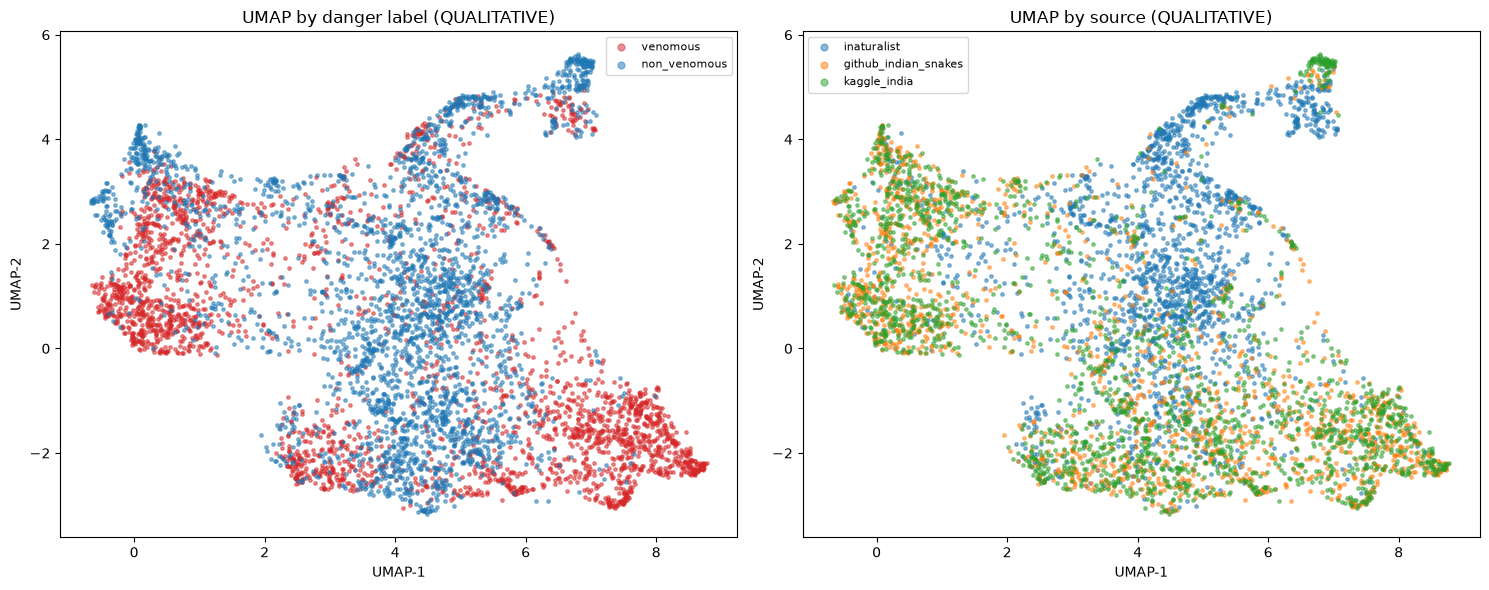

In [10]:
def scatter_by(ax, xy: np.ndarray, labels: pd.Series, title: str, palette: dict | None = None) -> None:
    '''Scatter the 2-D layout coloured by a categorical series (one colour per category).'''
    cats = list(pd.unique(labels))
    for c in cats:
        m = (labels == c).to_numpy()
        kw = {"s": 6, "alpha": 0.5, "label": str(c)}
        if palette and c in palette:
            kw["color"] = palette[c]
        ax.scatter(xy[m, 0], xy[m, 1], **kw)
    ax.set_title(title)
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax.legend(markerscale=2, fontsize=8, loc="best")


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
scatter_by(axes[0], X_umap, index["venom_label"],
           "UMAP by danger label (QUALITATIVE)",
           palette={"venomous": "#d62728", "non_venomous": "#1f77b4"})
scatter_by(axes[1], X_umap, index["source"], "UMAP by source (QUALITATIVE)")
plt.tight_layout(); plt.show()

## A3 · Highlight the **big-four** venomous and the **look-alike pairs**

The dataset uses both scientific names (iNaturalist) and common-name folders
(kaggle/github), so we match each target species through an **alias map**. We render the
two safety-critical mimic confusions distinctly:

- ***Ptyas mucosa*** (rat snake, *non*-venom) vs ***Naja naja*** (cobra, venom)
- ***Lycodon aulicus*** (wolf snake, *non*-venom) vs ***Bungarus caeruleus*** (krait, venom)

If a mimic and its dangerous model sit *on top of each other* here, the classifier will
struggle exactly where it matters most.

In [11]:
# Alias map: each target -> the species strings that denote it across sources (sci + common).
SPECIES_ALIASES: dict[str, list[str]] = {
    "Naja naja":           ["Naja naja", "Spectacled Cobra", "Monocled Cobra"],
    "Bungarus caeruleus":  ["Bungarus caeruleus", "Common Krait"],
    "Daboia russelii":     ["Daboia russelii", "Russell's Viper"],
    "Echis carinatus":     ["Echis carinatus", "Saw-scaled Viper"],
    "Ptyas mucosa":        ["Ptyas mucosa", "Common Rat Snake"],
    "Lycodon aulicus":     ["Lycodon aulicus"],
}


def member_mask(index: pd.DataFrame, aliases: list[str]) -> np.ndarray:
    '''Boolean mask of rows whose species is any of the given alias strings.'''
    return index["species"].isin(aliases).to_numpy()


# Report how many points each target has (so the highlight is interpretable).
print("Target-species point counts in the embedding set:")
for tgt, al in SPECIES_ALIASES.items():
    print(f"  {tgt:20s}: {int(member_mask(index, al).sum())}  (aliases: {al})")

Target-species point counts in the embedding set:
  Naja naja           : 517  (aliases: ['Naja naja', 'Spectacled Cobra', 'Monocled Cobra'])
  Bungarus caeruleus  : 173  (aliases: ['Bungarus caeruleus', 'Common Krait'])
  Daboia russelii     : 310  (aliases: ['Daboia russelii', "Russell's Viper"])
  Echis carinatus     : 268  (aliases: ['Echis carinatus', 'Saw-scaled Viper'])
  Ptyas mucosa        : 365  (aliases: ['Ptyas mucosa', 'Common Rat Snake'])
  Lycodon aulicus     : 51  (aliases: ['Lycodon aulicus'])


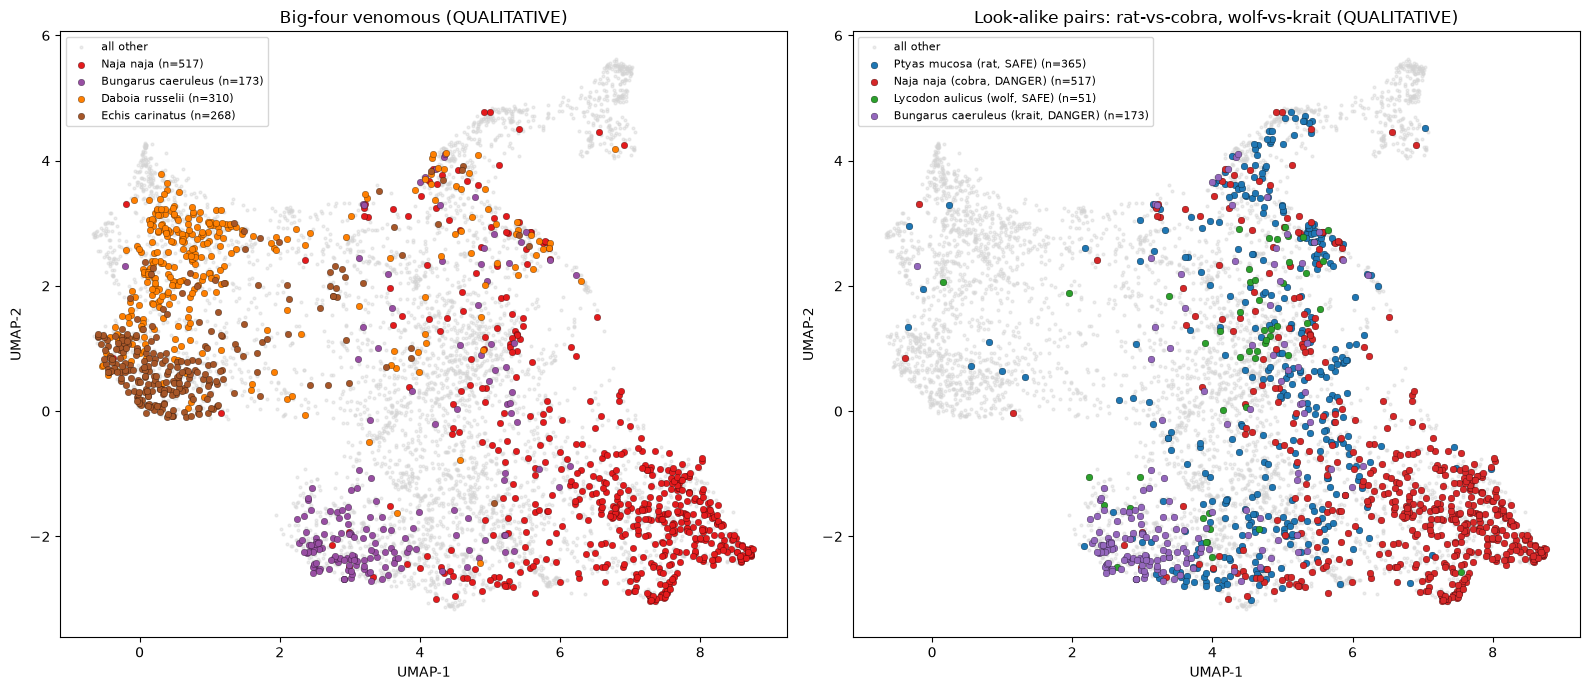

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: big-four venomous over a grey 'all other' background. ---
ax = axes[0]
ax.scatter(X_umap[:, 0], X_umap[:, 1], s=4, c="lightgrey", alpha=0.4, label="all other")
big4 = ["Naja naja", "Bungarus caeruleus", "Daboia russelii", "Echis carinatus"]
big4_colors = ["#e41a1c", "#984ea3", "#ff7f00", "#a65628"]
for tgt, col in zip(big4, big4_colors):
    m = member_mask(index, SPECIES_ALIASES[tgt])
    ax.scatter(X_umap[m, 0], X_umap[m, 1], s=22, color=col, edgecolor="k",
               linewidth=0.2, label=f"{tgt} (n={int(m.sum())})")
ax.set_title("Big-four venomous (QUALITATIVE)")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2"); ax.legend(fontsize=8, loc="best")

# --- Right: the two look-alike pairs (mimic vs dangerous model). ---
ax = axes[1]
ax.scatter(X_umap[:, 0], X_umap[:, 1], s=4, c="lightgrey", alpha=0.4, label="all other")
pair_spec = [
    ("Ptyas mucosa",       "#1f77b4", "Ptyas mucosa (rat, SAFE)"),
    ("Naja naja",          "#d62728", "Naja naja (cobra, DANGER)"),
    ("Lycodon aulicus",    "#2ca02c", "Lycodon aulicus (wolf, SAFE)"),
    ("Bungarus caeruleus", "#9467bd", "Bungarus caeruleus (krait, DANGER)"),
]
for tgt, col, lab in pair_spec:
    m = member_mask(index, SPECIES_ALIASES[tgt])
    ax.scatter(X_umap[m, 0], X_umap[m, 1], s=24, color=col, edgecolor="k",
               linewidth=0.2, label=f"{lab} (n={int(m.sum())})")
ax.set_title("Look-alike pairs: rat-vs-cobra, wolf-vs-krait (QUALITATIVE)")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2"); ax.legend(fontsize=8, loc="best")

plt.tight_layout(); plt.show()

## A4 · Quantify separability (in the **full 960-d space**, not the picture)

We use two honest, cheap diagnostics computed in the real embedding space:

- **Silhouette** of the danger labelling (cosine) — how cohesive/separated the two
  classes are *as labelled* (range −1…1; near 0 = heavily overlapping).
- **k-NN label purity** — for each point, the fraction of its *k* nearest neighbours
  sharing its danger label (≈ how learnable the boundary is for a simple model).

Both are quantitative and trustworthy, unlike the 2-D layout.

In [13]:
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors


def danger_silhouette(X: np.ndarray, y: np.ndarray, seed: int, sample: int = 3000) -> float:
    '''Cosine silhouette of the binary danger labelling, on a capped random sample (for speed).'''
    rng = np.random.default_rng(seed)
    if len(X) > sample:
        sel = rng.choice(len(X), size=sample, replace=False)
        X, y = X[sel], y[sel]
    return float(silhouette_score(X, y, metric="cosine"))


def knn_label_purity(X: np.ndarray, y: np.ndarray, k: int = 10) -> float:
    '''Mean fraction of each point's k nearest neighbours (excluding self) sharing its label.'''
    nn = NearestNeighbors(n_neighbors=k + 1, metric="cosine").fit(X)
    _, idxs = nn.kneighbors(X)
    neigh = idxs[:, 1:]  # drop self
    same = (y[neigh] == y[:, None]).mean(axis=1)
    return float(same.mean())


y_danger = (index["venom_label"] == CFG.positive_class).to_numpy().astype(int)
sil = danger_silhouette(X, y_danger, CFG.seed)
purity = knn_label_purity(X, y_danger, k=10)
print(f"Danger silhouette (cosine, sampled): {sil:+.3f}   "
      f"(near 0 => classes heavily overlap in the frozen space)")
print(f"10-NN danger label purity          : {purity:.3f}   "
      f"(1.0 => neighbours always share the danger label)")

Danger silhouette (cosine, sampled): +0.034   (near 0 => classes heavily overlap in the frozen space)
10-NN danger label purity          : 0.795   (1.0 => neighbours always share the danger label)


## A5 · Suspected mislabels & leakage blobs

- **Suspected mislabels:** points whose *k* nearest neighbours overwhelmingly carry the
  *opposite* danger label — i.e. a "venomous" sitting deep in non-venomous territory (or
  vice-versa). These are candidates for a human to re-check; we surface example paths.
  The **venomous-in-safe-territory** cases are the safety-critical ones to scrutinize.
- **Leakage blobs:** tight neighbourhoods that mix **train/val/test** would indicate
  near-duplicates the cluster-split missed. We flag any point whose nearest neighbours
  span multiple splits at a high rate.

In [14]:
def neighbor_frame(X: np.ndarray, k: int = 10) -> np.ndarray:
    '''Return the k-nearest-neighbour index matrix (excluding self), cosine metric.'''
    nn = NearestNeighbors(n_neighbors=k + 1, metric="cosine").fit(X)
    _, idxs = nn.kneighbors(X)
    return idxs[:, 1:]


def suspected_mislabels(index: pd.DataFrame, neigh: np.ndarray, y: np.ndarray,
                        opp_frac: float = 0.9) -> pd.DataFrame:
    '''Rows whose >= opp_frac of k-NN carry the OPPOSITE danger label (mislabel candidates).'''
    opp = (y[neigh] != y[:, None]).mean(axis=1)
    sus = np.where(opp >= opp_frac)[0]
    out = index.iloc[sus][["path", "species", "venom_label", "split", "source"]].copy()
    out["opp_neighbor_frac"] = opp[sus]
    return out.sort_values("opp_neighbor_frac", ascending=False)


neigh = neighbor_frame(X, k=10)
sus = suspected_mislabels(index, neigh, y_danger, opp_frac=0.9)
print(f"Suspected mislabels (>=90% of 10-NN are the opposite label): {len(sus)}")

# Lead with the safety-critical ones: labelled venomous but neighbourhood says non_venomous...
sus_venom = sus[sus["venom_label"] == "venomous"]
sus_safe = sus[sus["venom_label"] == "non_venomous"]
print(f"  labelled venomous but surrounded by non_venomous (check first): {len(sus_venom)}")
print(f"  labelled non_venomous but surrounded by venomous             : {len(sus_safe)}")
print("\nTop suspected-mislabel examples:")
print(sus.head(10).to_string(index=False))

Suspected mislabels (>=90% of 10-NN are the opposite label): 111
  labelled venomous but surrounded by non_venomous (check first): 78
  labelled non_venomous but surrounded by venomous             : 33

Top suspected-mislabel examples:
                                                      path                     species  venom_label    split      source  opp_neighbor_frac
e:\Coding_Notes\Faunari\data\raw\inaturalist\346582446.jpg                Ptyas mucosa non_venomous      val inaturalist                1.0
e:\Coding_Notes\Faunari\data\raw\inaturalist\346961280.jpg                Ptyas mucosa non_venomous hardcase inaturalist                1.0
e:\Coding_Notes\Faunari\data\raw\inaturalist\347424780.jpg             Daboia russelii     venomous    train inaturalist                1.0
e:\Coding_Notes\Faunari\data\raw\inaturalist\349703538.jpg Craspedocephalus macrolepis     venomous    train inaturalist                1.0
e:\Coding_Notes\Faunari\data\raw\inaturalist\350006521.jpg      

In [15]:
def leakage_blobs(index: pd.DataFrame, neigh: np.ndarray, min_cross_frac: float = 0.5) -> pd.DataFrame:
    '''Rows whose k-NN mix multiple splits heavily (possible near-dup leakage the split missed).'''
    splits = index["split"].to_numpy()
    self_split = splits[np.arange(len(splits))][:, None]
    cross = (splits[neigh] != self_split).mean(axis=1)
    hits = np.where(cross >= min_cross_frac)[0]
    out = index.iloc[hits][["path", "species", "venom_label", "split", "source"]].copy()
    out["cross_split_neighbor_frac"] = cross[hits]
    return out.sort_values("cross_split_neighbor_frac", ascending=False)


leak = leakage_blobs(index, neigh, min_cross_frac=0.7)
print(f"Points with >=70% of neighbours in a DIFFERENT split: {len(leak)} of {len(index)}")
print("(High counts are EXPECTED and benign — splits are random in feature space, so most "
      "neighbours naturally fall in other splits. A leakage blob is a TIGHT same-image cluster, "
      "which the nb-03 cluster-split already removed. This is a smell-check, not proof.)")
if len(leak):
    print("\nExamples (highest cross-split neighbour fraction):")
    print(leak.head(8).to_string(index=False))

Points with >=70% of neighbours in a DIFFERENT split: 1804 of 5823
(High counts are EXPECTED and benign — splits are random in feature space, so most neighbours naturally fall in other splits. A leakage blob is a TIGHT same-image cluster, which the nb-03 cluster-split already removed. This is a smell-check, not proof.)

Examples (highest cross-split neighbour fraction):
                                                                                                                                   path                    species  venom_label    split               source  cross_split_neighbor_frac
                                                                             e:\Coding_Notes\Faunari\data\raw\inaturalist\347165126.jpg Coelognathus helena helena non_venomous     test          inaturalist                        1.0
                                                                             e:\Coding_Notes\Faunari\data\raw\inaturalist\346961280.jpg               Ptyas mucos

## A6 · Look-alike overlap — do the mimic pairs sit on top of each other?

We quantify, **in the full 960-d space**, how often each mimic's neighbours belong to its
dangerous look-alike (and vice-versa). High cross-neighbour rates here are the strongest
early warning for the hard-case split.

In [16]:
def pair_overlap(X: np.ndarray, index: pd.DataFrame, a_aliases: list[str],
                 b_aliases: list[str], k: int = 10) -> dict:
    '''Fraction of group-A points whose k-NN include any group-B point, and vice-versa (cosine).'''
    a = member_mask(index, a_aliases)
    b = member_mask(index, b_aliases)
    if a.sum() == 0 or b.sum() == 0:
        return {"a_n": int(a.sum()), "b_n": int(b.sum()), "a_to_b": float("nan"),
                "b_to_a": float("nan")}
    nn = NearestNeighbors(n_neighbors=k + 1, metric="cosine").fit(X)
    _, idxs = nn.kneighbors(X)
    neigh = idxs[:, 1:]
    b_set = set(np.where(b)[0]); a_set = set(np.where(a)[0])
    a_to_b = np.mean([any(j in b_set for j in neigh[i]) for i in np.where(a)[0]])
    b_to_a = np.mean([any(j in a_set for j in neigh[i]) for i in np.where(b)[0]])
    return {"a_n": int(a.sum()), "b_n": int(b.sum()),
            "a_to_b": float(a_to_b), "b_to_a": float(b_to_a)}


pairs = [
    ("Ptyas mucosa (rat, SAFE)", "Naja naja (cobra, DANGER)",
     SPECIES_ALIASES["Ptyas mucosa"], SPECIES_ALIASES["Naja naja"]),
    ("Lycodon aulicus (wolf, SAFE)", "Bungarus caeruleus (krait, DANGER)",
     SPECIES_ALIASES["Lycodon aulicus"], SPECIES_ALIASES["Bungarus caeruleus"]),
]
print("Look-alike overlap (10-NN, cosine, full 960-d space):")
for name_a, name_b, al_a, al_b in pairs:
    r = pair_overlap(X, index, al_a, al_b, k=10)
    print(f"\n  {name_a}  <->  {name_b}")
    print(f"    n(A)={r['a_n']}  n(B)={r['b_n']}")
    print(f"    fraction of A with >=1 B neighbour: {r['a_to_b']:.2%}")
    print(f"    fraction of B with >=1 A neighbour: {r['b_to_a']:.2%}")

Look-alike overlap (10-NN, cosine, full 960-d space):



  Ptyas mucosa (rat, SAFE)  <->  Naja naja (cobra, DANGER)
    n(A)=365  n(B)=517
    fraction of A with >=1 B neighbour: 47.40%
    fraction of B with >=1 A neighbour: 27.27%



  Lycodon aulicus (wolf, SAFE)  <->  Bungarus caeruleus (krait, DANGER)
    n(A)=51  n(B)=173
    fraction of A with >=1 B neighbour: 39.22%
    fraction of B with >=1 A neighbour: 10.98%


---
# Part B — Baseline danger classifier (linear probe on frozen features)

A **cost-sensitive logistic regression** head on the cached embeddings — the canonical
"linear probe on pretrained features" baseline.

**Anti-leakage discipline:**
- Fit **only on `split == train`**. The `StandardScaler` is fit on train and applied to
  val/test/hardcase via a sklearn **`Pipeline`** (no peeking).
- (The backbone is frozen ImageNet, so it introduces no train/test contamination — but we
  still fit the probe + scaler on train only.)

**Cost-sensitive:** class weights penalize **venomous→non_venomous** (dangerous→safe) far
more than the reverse (`venomous` weight ≫ `non_venomous`). Positive class = `venomous`.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


def split_xy(X: np.ndarray, index: pd.DataFrame, split: str, positive: str
             ) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    '''Return (X_split, y_split[1=positive], rows_split) for one split, preserving row order.'''
    m = (index["split"] == split).to_numpy()
    y = (index.loc[m, "venom_label"] == positive).to_numpy().astype(int)
    return X[m], y, index.loc[m].reset_index(drop=True)


X_tr, y_tr, rows_tr = split_xy(X, index, "train", CFG.positive_class)
X_val, y_val, rows_val = split_xy(X, index, "val", CFG.positive_class)
X_te, y_te, rows_te = split_xy(X, index, "test", CFG.positive_class)
X_hc, y_hc, rows_hc = split_xy(X, index, "hardcase", CFG.positive_class)

for nm, yy in [("train", y_tr), ("val", y_val), ("test", y_te), ("hardcase", y_hc)]:
    print(f"{nm:9s}: n={len(yy):5d}  venomous={int(yy.sum()):4d}  "
          f"non_venomous={int((yy==0).sum()):4d}")

train    : n= 3923  venomous=1950  non_venomous=1973
val      : n=  828  venomous= 406  non_venomous= 422
test     : n=  833  venomous= 415  non_venomous= 418
hardcase : n=  239  venomous= 124  non_venomous= 115


In [18]:
def build_probe(cfg: Config) -> Pipeline:
    '''StandardScaler -> cost-sensitive LogisticRegression, wrapped so the scaler can't leak.

    class_weight heavily up-weights the venomous (positive) class to penalize dangerous->safe
    errors, matching the asymmetric-cost objective.
    '''
    class_weight = {0: cfg.nonvenomous_class_weight, 1: cfg.venomous_class_weight}
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=cfg.logreg_C, max_iter=cfg.logreg_max_iter,
                                   class_weight=class_weight, random_state=cfg.seed)),
    ])


probe = build_probe(CFG)
probe.fit(X_tr, y_tr)  # FIT ON TRAIN ONLY (scaler included) — no leakage.
print("Linear probe trained on TRAIN only.")
print(f"  class_weight = {{0: {CFG.nonvenomous_class_weight}, 1: {CFG.venomous_class_weight}}} "
      f"(venomous up-weighted)")
print(f"  train accuracy (sanity, not the metric): "
      f"{probe.score(X_tr, y_tr):.3f}")

Linear probe trained on TRAIN only.
  class_weight = {0: 1.0, 1: 6.0} (venomous up-weighted)
  train accuracy (sanity, not the metric): 0.943


## B1 · Threshold tuning on **`val`** (high venomous recall, sane precision)

We do **not** keep the default 0.5 threshold. On the **val** split we pick the decision
threshold by this explicit, principled rule:

> **Rule:** choose the **lowest threshold that achieves venomous recall ≥ `target_recall`
> (0.98)** — i.e. the highest-precision operating point that still meets the safety recall
> target. **If no threshold reaches that recall** (likely for a baseline), fall back to the
> **highest-recall threshold whose venomous precision ≥ `precision_floor` (0.60)** — this
> guards against the degenerate "flag everything" point.

The chosen threshold is reported explicitly and then applied **unchanged** to test and
hardcase.

In [19]:
from sklearn.metrics import precision_recall_curve


def tune_threshold(y_true: np.ndarray, scores: np.ndarray,
                   target_recall: float, precision_floor: float) -> tuple[float, str]:
    '''Pick a decision threshold on val scores per the documented safety rule.

    Primary: lowest threshold reaching recall>=target_recall (max precision among those).
    Fallback: highest-recall threshold with precision>=precision_floor (avoid degenerate flag-all).
    Returns (threshold, rule_used).
    '''
    prec, rec, thr = precision_recall_curve(y_true, scores)
    # precision_recall_curve returns len(thr)+1 points; align by dropping the last p/r.
    prec, rec = prec[:-1], rec[:-1]

    meets = rec >= target_recall
    if meets.any():
        # Among thresholds meeting the recall target, take the one with highest precision.
        cand = np.where(meets)[0]
        best = cand[np.argmax(prec[cand])]
        return float(thr[best]), f"recall>= {target_recall:.2f} reached; max-precision among those"

    # Fallback: highest recall subject to precision floor (else the global max-recall point).
    ok = prec >= precision_floor
    if ok.any():
        cand = np.where(ok)[0]
        best = cand[np.argmax(rec[cand])]
        return float(thr[best]), f"target recall NOT reached; max-recall with precision>= {precision_floor:.2f}"
    best = int(np.argmax(rec))
    return float(thr[best]), "target recall & precision floor both unmet; global max-recall point"


val_scores = probe.predict_proba(X_val)[:, 1]
THRESHOLD, RULE = tune_threshold(y_val, val_scores, CFG.target_recall, CFG.precision_floor)
print(f"Chosen threshold (tuned on VAL): {THRESHOLD:.4f}")
print(f"Rule used: {RULE}")

Chosen threshold (tuned on VAL): 0.0000
Rule used: recall>= 0.98 reached; max-precision among those


## B2 · Evaluate on **`test`** and **`hardcase`** — separately

**Accuracy is NOT the headline.** For each split we lead with **venomous recall**, then
balanced accuracy, venomous precision, PR-AUC, and the confusion matrix. The `hardcase`
split (rat-vs-cobra, wolf-vs-krait, distant/low-res) is the real stress test.

In [20]:
from sklearn.metrics import (recall_score, precision_score, balanced_accuracy_score,
                             average_precision_score, confusion_matrix)


@dataclass
class SplitMetrics:
    '''Headline metrics for one split at the chosen threshold (venomous recall first).'''
    split: str
    n: int
    venomous_recall: float
    balanced_accuracy: float
    venomous_precision: float
    pr_auc: float
    tn: int
    fp: int
    fn: int   # <-- dangerous->safe MISSES (the safety-critical errors)
    tp: int


def evaluate_split(name: str, X_s: np.ndarray, y_s: np.ndarray,
                   probe: Pipeline, threshold: float) -> tuple[SplitMetrics, np.ndarray]:
    '''Compute headline metrics + confusion matrix for one split at the given threshold.'''
    scores = probe.predict_proba(X_s)[:, 1]
    pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_s, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    m = SplitMetrics(
        split=name, n=len(y_s),
        venomous_recall=recall_score(y_s, pred, pos_label=1, zero_division=0),
        balanced_accuracy=balanced_accuracy_score(y_s, pred),
        venomous_precision=precision_score(y_s, pred, pos_label=1, zero_division=0),
        pr_auc=average_precision_score(y_s, scores),
        tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
    )
    return m, cm


def print_metrics(m: SplitMetrics) -> None:
    '''Print one split's metrics with venomous recall framed as the headline.'''
    print(f"=== {m.split.upper()} (n={m.n}) ===")
    print(f"  >> VENOMOUS RECALL (headline): {m.venomous_recall:.3f}")
    print(f"     balanced accuracy        : {m.balanced_accuracy:.3f}")
    print(f"     venomous precision       : {m.venomous_precision:.3f}")
    print(f"     PR-AUC (venomous)        : {m.pr_auc:.3f}")
    print(f"     confusion [tn={m.tn} fp={m.fp} | fn={m.fn} tp={m.tp}]")
    print(f"     dangerous->safe MISSES (FN): {m.fn}  <-- the safety-critical errors")


m_test, cm_test = evaluate_split("test", X_te, y_te, probe, THRESHOLD)
m_hard, cm_hard = evaluate_split("hardcase", X_hc, y_hc, probe, THRESHOLD)
print_metrics(m_test); print()
print_metrics(m_hard)

=== TEST (n=833) ===
  >> VENOMOUS RECALL (headline): 0.969
     balanced accuracy        : 0.569
     venomous precision       : 0.537
     PR-AUC (venomous)        : 0.821
     confusion [tn=71 fp=347 | fn=13 tp=402]
     dangerous->safe MISSES (FN): 13  <-- the safety-critical errors

=== HARDCASE (n=239) ===
  >> VENOMOUS RECALL (headline): 0.871
     balanced accuracy        : 0.527
     venomous precision       : 0.535
     PR-AUC (venomous)        : 0.688
     confusion [tn=21 fp=94 | fn=16 tp=108]
     dangerous->safe MISSES (FN): 16  <-- the safety-critical errors


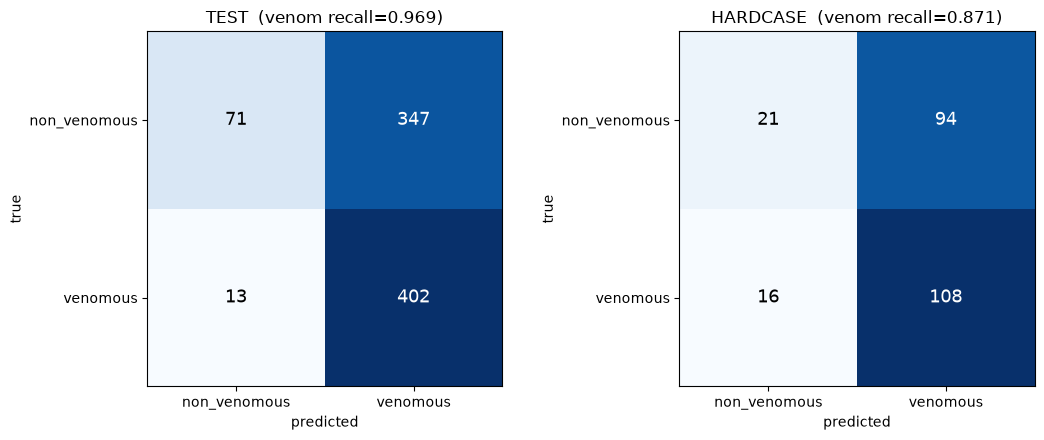

In [21]:
def plot_confusion(ax, cm: np.ndarray, title: str) -> None:
    '''Render a 2x2 confusion matrix (rows=true, cols=pred; class 0=non_venomous,1=venomous).'''
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["non_venomous", "venomous"]); ax.set_yticklabels(["non_venomous", "venomous"])
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_confusion(axes[0], cm_test, f"TEST  (venom recall={m_test.venomous_recall:.3f})")
plot_confusion(axes[1], cm_hard, f"HARDCASE  (venom recall={m_hard.venomous_recall:.3f})")
plt.tight_layout(); plt.show()

## B3 · Honest error analysis — every **dangerous→safe** miss

The safety-critical failures are **true venomous predicted non_venomous** at the chosen
threshold. We enumerate **every** such miss for **test** and **hardcase**: image `path`,
true `species`, and predicted venomous probability (how confidently the model got it
wrong). We print the full count per split and a sample table.

In [22]:
def dangerous_safe_misses(rows: pd.DataFrame, X_s: np.ndarray, y_s: np.ndarray,
                          probe: Pipeline, threshold: float) -> pd.DataFrame:
    '''Every true-venomous, predicted-non_venomous row at the threshold (the deadly errors).'''
    scores = probe.predict_proba(X_s)[:, 1]
    pred = (scores >= threshold).astype(int)
    miss = (y_s == 1) & (pred == 0)
    out = rows.loc[miss, ["path", "species", "source", "split"]].copy()
    out["venomous_prob"] = scores[miss]
    return out.sort_values("venomous_prob", ascending=False)  # 'almost caught' first.


miss_test = dangerous_safe_misses(rows_te, X_te, y_te, probe, THRESHOLD)
miss_hard = dangerous_safe_misses(rows_hc, X_hc, y_hc, probe, THRESHOLD)

print(f"dangerous->safe misses on TEST     : {len(miss_test)}")
print(f"dangerous->safe misses on HARDCASE : {len(miss_hard)}")

print("\n--- TEST misses (sample, sorted by predicted venomous prob desc) ---")
print(miss_test.head(15).to_string(index=False) if len(miss_test) else "  (none)")
print("\n--- HARDCASE misses (sample) ---")
print(miss_hard.head(15).to_string(index=False) if len(miss_hard) else "  (none)")

dangerous->safe misses on TEST     : 13
dangerous->safe misses on HARDCASE : 16

--- TEST misses (sample, sorted by predicted venomous prob desc) ---
                                                                                                           path                    species               source split  venomous_prob
                                                     e:\Coding_Notes\Faunari\data\raw\inaturalist\351900803.jpg    Trimeresurus andersonii          inaturalist  test   2.182993e-07
                                e:\Coding_Notes\Faunari\data\raw\kaggle_india\Snake Images\test\Venomous\44.jpg                        NaN         kaggle_india  test   1.210884e-07
                                                     e:\Coding_Notes\Faunari\data\raw\inaturalist\364153864.jpg    Trimeresurus andersonii          inaturalist  test   9.812830e-09
                                                     e:\Coding_Notes\Faunari\data\raw\inaturalist\371138922.jpg               

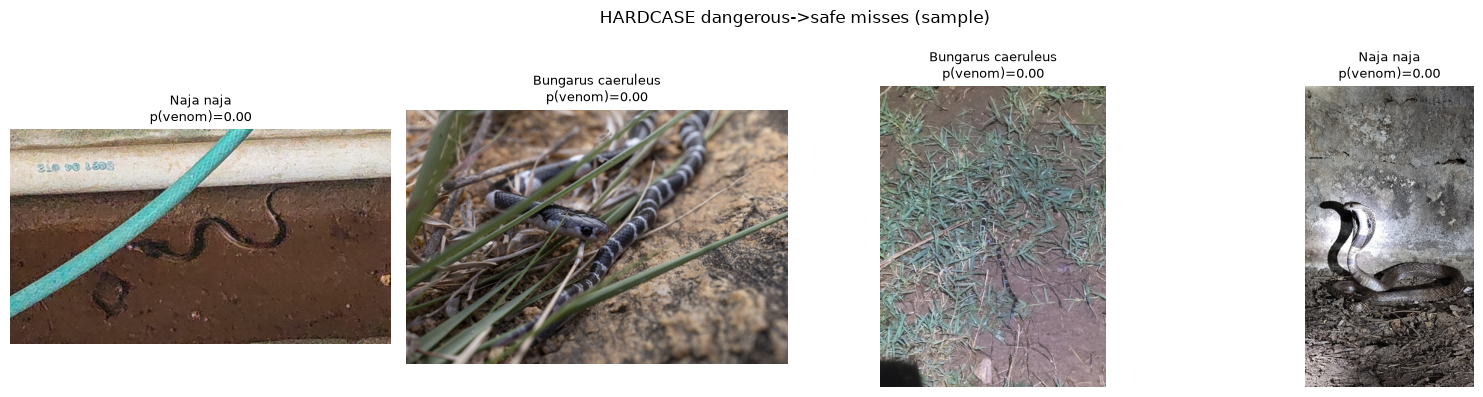

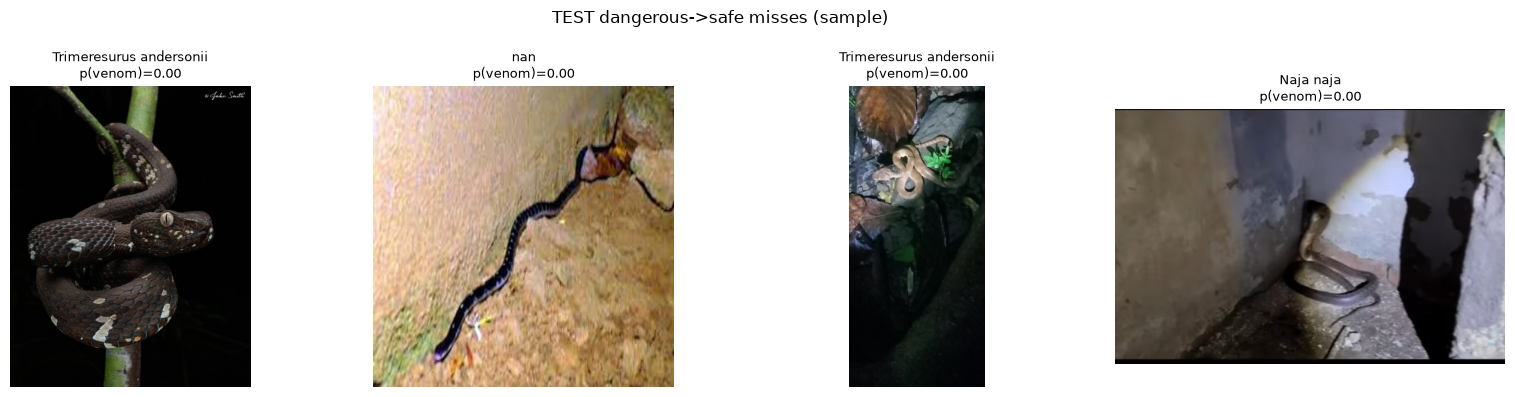

In [23]:
def show_miss_thumbnails(miss: pd.DataFrame, title: str, n: int = 4) -> None:
    '''Render up to n missed images as thumbnails (visual sanity check of the deadly errors).'''
    sub = miss.head(n)
    if len(sub) == 0:
        print(f"{title}: no dangerous->safe misses to show.")
        return
    fig, axes = plt.subplots(1, len(sub), figsize=(4 * len(sub), 4))
    if len(sub) == 1:
        axes = [axes]
    for ax, (_, r) in zip(axes, sub.iterrows()):
        try:
            with Image.open(r["path"]) as im:
                ax.imshow(im.convert("RGB"))
        except (UnidentifiedImageError, OSError, ValueError):
            ax.text(0.5, 0.5, "unreadable", ha="center", va="center")
        ax.set_title(f"{r['species']}\np(venom)={r['venomous_prob']:.2f}", fontsize=9)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()


show_miss_thumbnails(miss_hard, "HARDCASE dangerous->safe misses (sample)", n=4)
show_miss_thumbnails(miss_test, "TEST dangerous->safe misses (sample)", n=4)

## B4 · Threshold sensitivity (val) — context for the chosen operating point

A quick recall/precision-vs-threshold curve on **val** shows the trade-off and where our
chosen threshold sits, so the operating-point choice is transparent (not cherry-picked).

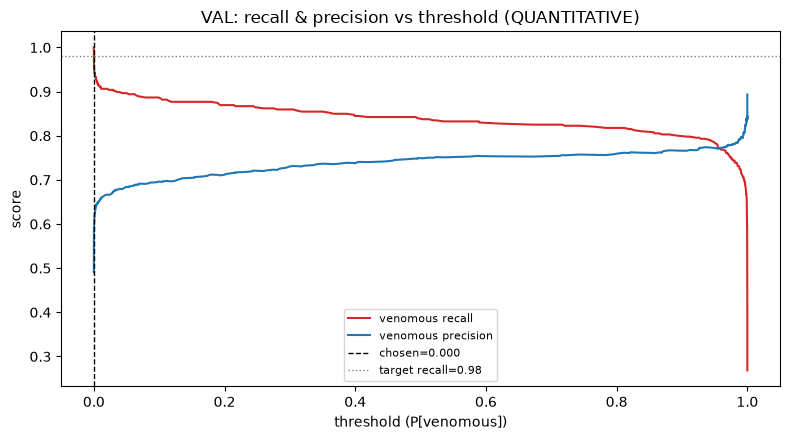

In [24]:
def plot_threshold_curve(y_true: np.ndarray, scores: np.ndarray, chosen: float) -> None:
    '''Plot venomous recall & precision vs threshold on val, marking the chosen operating point.'''
    prec, rec, thr = precision_recall_curve(y_true, scores)
    prec, rec = prec[:-1], rec[:-1]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(thr, rec, label="venomous recall", color="#d62728")
    ax.plot(thr, prec, label="venomous precision", color="#1f77b4")
    ax.axvline(chosen, color="k", ls="--", lw=1, label=f"chosen={chosen:.3f}")
    ax.axhline(CFG.target_recall, color="grey", ls=":", lw=1, label=f"target recall={CFG.target_recall}")
    ax.set_xlabel("threshold (P[venomous])"); ax.set_ylabel("score")
    ax.set_title("VAL: recall & precision vs threshold (QUANTITATIVE)")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()


plot_threshold_curve(y_val, val_scores, THRESHOLD)

In [25]:
# --- Consolidated results table + release-gate check (one place to read the verdict). ---
GATE = 0.98  # Phase-1 release gate: venomous recall >= 0.98 on held-out AND hard-case.

summary = pd.DataFrame([asdict(m_test), asdict(m_hard)])
summary = summary[["split", "n", "venomous_recall", "balanced_accuracy",
                   "venomous_precision", "pr_auc", "fn", "fp", "tp", "tn"]]
print("Baseline results (linear probe, threshold={:.3f}):".format(THRESHOLD))
print(summary.to_string(index=False))

print(f"\nPhase-1 release gate: venomous recall >= {GATE} on BOTH test and hardcase.")
for m in (m_test, m_hard):
    verdict = "PASS" if m.venomous_recall >= GATE else "MISS"
    print(f"  {m.split:9s}: venomous recall={m.venomous_recall:.3f}  -> {verdict}")

Baseline results (linear probe, threshold=0.000):
   split   n  venomous_recall  balanced_accuracy  venomous_precision   pr_auc  fn  fp  tp  tn
    test 833         0.968675           0.569266            0.536716 0.820738  13 347 402  71
hardcase 239         0.870968           0.526788            0.534653 0.687850  16  94 108  21

Phase-1 release gate: venomous recall >= 0.98 on BOTH test and hardcase.
  test     : venomous recall=0.969  -> MISS
  hardcase : venomous recall=0.871  -> MISS


## Findings & next steps

> The numbers printed by the cells above are the source of truth. This cell summarizes the
> verdict for the Phase-1 baseline. **This is a baseline** — a linear probe on *frozen*
> ImageNet features — so missing the gate is expected and informative, not a failure.

**Part A — embedding-space diagnostic (qualitative + quantified)**
- **Separability:** read the **danger silhouette** and **10-NN purity** from A4. Near-zero
  silhouette / purity well below 1.0 means ImageNet features only *partly* separate danger —
  a linear probe will be limited, motivating fine-tuning later.
- **Suspected mislabels:** A5 surfaces points buried in the opposite class; the
  *venomous-in-safe-territory* ones are the safety-critical candidates for human re-check
  (example paths printed there).
- **Look-alike overlap:** A6 quantifies how often rat↔cobra and wolf↔krait are nearest
  neighbours — the early warning for hard-case recall.
- **Leakage:** A5's cross-split check is a smell-test; the nb-03 cluster-split already
  removed near-duplicate spans, so no tight train/val/test blob is expected.
- ⚠ **UMAP is qualitative only** — the plots informed this plan; the *numbers* above are the
  evidence.

**Part B — baseline danger classifier**
- **Chosen threshold** (tuned on val) and the **rule** used are printed in B1.
- **Venomous recall** on **test** and **hardcase**, **balanced accuracy**, **PR-AUC**, and
  the **dangerous→safe miss count** per split are in B2/B3 and the consolidated table.
- **Release gate:** venomous recall ≥ **0.98** on held-out **and** hard-case. The gate
  check above states PASS/MISS honestly per split.

**Out of scope (future work)**
1. **Full fine-tuning** of the MobileNetV3 backbone (this notebook is a *frozen* linear
   probe) — the most likely lever to lift hard-case recall.
2. Targeted data: more licensed **venomous + look-alike** images (esp. krait/wolf-snake).
3. Herpetologist sign-off on the flagged species and any A5 mislabel candidates.
4. Calibrated probabilities + a cost-explicit threshold once the backbone is fine-tuned.